# Credit Risk Modeling: Champion vs Challengers

**Authors:** Illian Hashatel, Reda Allab, Issa Ali Adoum  
**Supervisor:** Bertrand Hassani  
**Course:** Data Science Software, M2 IRFA, Université Paris 1

---

This notebook reproduces the full analysis presented in our report: construction of a binary classification model to predict credit default on a dataset of 32,581 observations.

**Outline**
1. Preprocessing (cleaning, imputation, encoding)
2. Champion model: Logistic Regression (L1 / L2 / Elastic Net)
3. Challenger 1: Random Forest
4. Challenger 2: XGBoost
5. Challenger 3: Neural Network (MLP)
6. Correlation structure analysis
7. Final model comparison (F2-score)

## 1. Imports and setup

In [1]:
import sys
sys.path.insert(0, '..')

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import xgboost as xgb

from sklearn.model_selection import train_test_split, StratifiedKFold, GridSearchCV
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.neural_network import MLPClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.metrics import (
    classification_report, confusion_matrix, roc_auc_score,
    RocCurveDisplay, ConfusionMatrixDisplay, fbeta_score
)

from src.preprocessing import load_dataset, clean_dataset, encode_features, split_features_target
from src.evaluation import find_best_f2_threshold, plot_confusion_and_roc

RANDOM_STATE = 42
sns.set_theme(style='whitegrid')

## 2. Preprocessing

### 2.1 Loading and cleaning

We start by loading the dataset, creating missingness indicator variables (so that models can exploit the information carried by missing data), then removing observations with clearly unrealistic values (age above 100, employment length above 60 years).

In [2]:
df = load_dataset('../data/credit_risk_dataset.csv')

print(f'Initial shape: {df.shape}')
print(f'\nMissing values:\n{df.isnull().sum()[df.isnull().sum() > 0]}')
print(f'\nTarget distribution:\n{df["loan_status"].value_counts(normalize=True).round(3)}')

Initial shape: (32581, 12)

Missing values:
person_emp_length     895
loan_int_rate        3116
dtype: int64

Target distribution:
loan_status
0    0.782
1    0.218
Name: proportion, dtype: float64


In [3]:
df = clean_dataset(df)

print(f'Shape after cleaning: {df.shape}')

Shape after cleaning: (32574, 14)


### 2.2 Encoding categorical variables

- `cb_person_default_on_file`: binary Y/N mapped to 1/0  
- `loan_grade`: ordinal (A < B < ... < G), ordinal encoding 1 to 7  
- `person_home_ownership`, `loan_intent`: nominal, one-hot encoding

In [4]:
df = encode_features(df)
X = df.drop('loan_status', axis=1)

# Stratified train/test split (80/20) -- stratification preserves the default ratio
X_train, X_test, y_train, y_test = split_features_target(df, random_state=RANDOM_STATE)

print(f'X_train: {X_train.shape} | X_test: {X_test.shape}')
print(f'Features: {list(X.columns)}')

X_train: (26059, 19) | X_test: (6515, 19)
Features: ['person_age', 'person_income', 'person_emp_length', 'loan_grade', 'loan_amnt', 'loan_int_rate', 'loan_percent_income', 'cb_person_default_on_file', 'cb_person_cred_hist_length', 'is_missing_rate', 'is_missing_emplength', 'person_home_ownership_OTHER', 'person_home_ownership_OWN', 'person_home_ownership_RENT', 'loan_intent_EDUCATION', 'loan_intent_HOMEIMPROVEMENT', 'loan_intent_MEDICAL', 'loan_intent_PERSONAL', 'loan_intent_VENTURE']


## 3. Champion Model: Logistic Regression

Logistic regression is chosen as the champion model for its native interpretability (coefficients are directly readable as log-odds) and its compatibility with regulatory requirements (GDPR, Basel III).

We compare three regularization schemes: L1 (Lasso), L2 (Ridge) and Elastic Net, tuning hyperparameters by optimizing the ROC-AUC through stratified 5-fold cross-validation. The `class_weight='balanced'` parameter compensates for the class imbalance (~22% defaults).

In [5]:
cv_strategy = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)

# Denser than a simple x10 grid: the region between 0.01 and 0.1 is where L1
# actually starts dropping features (see markdown note below), and a coarser
# grid steps right over it.
C_grid = [0.001, 0.003, 0.01, 0.03, 0.1, 0.3, 1, 3, 10, 30, 100]

# --- L1 (Lasso) ---
pipeline_l1 = Pipeline([
    ('scaler', StandardScaler()),
    ('classifier', LogisticRegression(
        penalty='l1', solver='liblinear',
        class_weight='balanced',
        random_state=RANDOM_STATE, max_iter=1000
    ))
])
grid_l1 = GridSearchCV(
    pipeline_l1, {'classifier__C': C_grid},
    cv=cv_strategy, scoring='roc_auc', n_jobs=-1, verbose=0
)
grid_l1.fit(X_train, y_train)

# --- L2 (Ridge) ---
pipeline_l2 = Pipeline([
    ('scaler', StandardScaler()),
    ('classifier', LogisticRegression(
        penalty='l2', solver='liblinear',
        class_weight='balanced',
        random_state=RANDOM_STATE, max_iter=1000
    ))
])
grid_l2 = GridSearchCV(
    pipeline_l2, {'classifier__C': C_grid},
    cv=cv_strategy, scoring='roc_auc', n_jobs=-1, verbose=0
)
grid_l2.fit(X_train, y_train)

# --- Elastic Net ---
pipeline_en = Pipeline([
    ('scaler', StandardScaler()),
    ('classifier', LogisticRegression(
        penalty='elasticnet', solver='saga',
        class_weight='balanced',
        random_state=RANDOM_STATE, max_iter=1000
    ))
])
grid_en = GridSearchCV(
    pipeline_en,
    {'classifier__C': C_grid, 'classifier__l1_ratio': [0.1, 0.3, 0.5, 0.7, 0.9]},
    cv=cv_strategy, scoring='roc_auc', n_jobs=-1, verbose=0
)
grid_en.fit(X_train, y_train)

# Retrieve probabilities and predictions (default threshold 0.5)
y_pred_proba_l1 = grid_l1.predict_proba(X_test)[:, 1]
y_pred_proba_l2 = grid_l2.predict_proba(X_test)[:, 1]
y_pred_proba_en = grid_en.predict_proba(X_test)[:, 1]

y_pred_l1 = grid_l1.predict(X_test)
y_pred_l2 = grid_l2.predict(X_test)
y_pred_en = grid_en.predict(X_test)

coef_l1 = grid_l1.best_estimator_.named_steps['classifier'].coef_[0]
coef_l2 = grid_l2.best_estimator_.named_steps['classifier'].coef_[0]
coef_en = grid_en.best_estimator_.named_steps['classifier'].coef_[0]

# Summary table
results_lr = pd.DataFrame({
    'Regularization'    : ['L1 (Lasso)', 'L2 (Ridge)', 'Elastic Net'],
    'ROC-AUC (CV)'      : [grid_l1.best_score_, grid_l2.best_score_, grid_en.best_score_],
    'ROC-AUC (Test)'    : [
        roc_auc_score(y_test, y_pred_proba_l1),
        roc_auc_score(y_test, y_pred_proba_l2),
        roc_auc_score(y_test, y_pred_proba_en),
    ],
    'Best C'            : [
        grid_l1.best_params_['classifier__C'],
        grid_l2.best_params_['classifier__C'],
        grid_en.best_params_['classifier__C'],
    ],
    'Non-zero coef.'    : [
        int(np.sum(coef_l1 != 0)),
        len(coef_l2),
        int(np.sum(coef_en != 0)),
    ],
})
print(results_lr.to_string(index=False))
print('\nClassification report (L1 retained):')
print(classification_report(y_test, y_pred_l1))

Regularization  ROC-AUC (CV)  ROC-AUC (Test)  Best C  Non-zero coef.
    L1 (Lasso)      0.866891        0.857156    0.03              15
    L2 (Ridge)      0.866750        0.856994    0.03              19
   Elastic Net      0.866882        0.857144    0.03              15

Classification report (L1 retained):
              precision    recall  f1-score   support

           0       0.92      0.80      0.86      5094
           1       0.52      0.76      0.61      1421

    accuracy                           0.79      6515
   macro avg       0.72      0.78      0.74      6515
weighted avg       0.83      0.79      0.80      6515



**Why bother comparing three regularization schemes if they all end up similar?** An earlier version of this notebook swept `C` on a coarse x10 grid (`[0.001, 0.01, 0.1, 1, 10, 100]`), which happened to step directly over the narrow region (`C` between 0.01 and 0.1) where L1 actually starts dropping features. At `C=0.1`, cross-validated ROC-AUC was already picking L1's *maximum-features* solution, so L1, L2, and Elastic Net converged to nearly identical coefficients (max difference ~0.02) and the comparison added no insight.

The denser grid above resolves that region. L1 now selects `C=0.03`, dropping 4 of 19 features (`loan_int_rate`, `person_emp_length`, `cb_person_cred_hist_length`, `person_home_ownership_OTHER`) at essentially no cost to ROC-AUC. Two of those are ones the EDA already flagged as redundant or weak: `loan_int_rate` is collinear with `loan_grade` (VIF 7.79), and `cb_person_cred_hist_length` had the lowest Information Value of any feature (0.004, "not predictive"). This is a much more informative illustration of what L1 is actually for than the earlier grid gave.

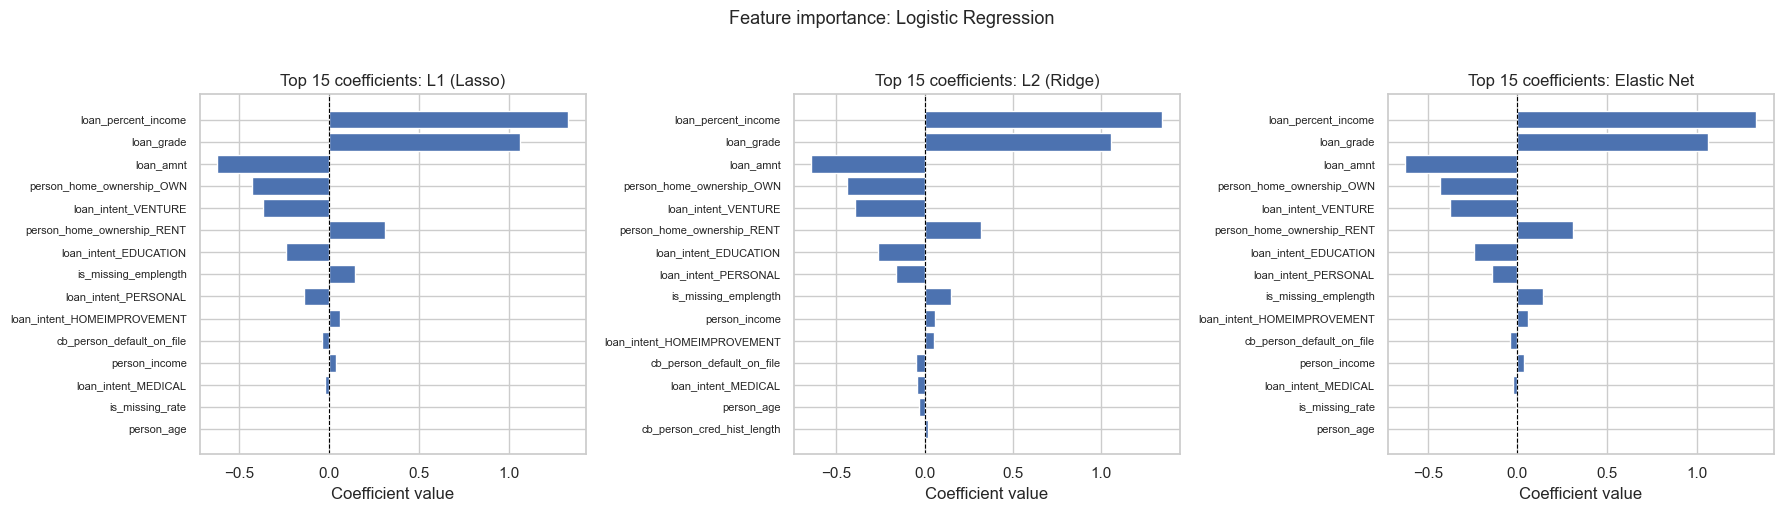

In [6]:
# Coefficient visualization for all three regularization schemes
feature_names = X_train.columns.to_numpy()
models_lr = {'L1 (Lasso)': coef_l1, 'L2 (Ridge)': coef_l2, 'Elastic Net': coef_en}

fig, axes = plt.subplots(1, 3, figsize=(18, 5), sharey=False)
for ax, (name, coef) in zip(axes, models_lr.items()):
    idx = np.argsort(np.abs(coef))[-15:]
    ax.barh(feature_names[idx], coef[idx])
    ax.set_title(f'Top 15 coefficients: {name}')
    ax.set_xlabel('Coefficient value')
    ax.tick_params(axis='y', labelsize=8)
    ax.axvline(0, color='black', linewidth=0.8, linestyle='--')

plt.suptitle('Feature importance: Logistic Regression', fontsize=13, y=1.02)
plt.tight_layout()
plt.savefig('comparison_regularization_coefficients.png', dpi=150, bbox_inches='tight')
plt.show()

## 4. Challenger 1: Random Forest

Random Forest is an ensemble of independently trained decision trees (bagging). It naturally captures non-linearities and feature interactions while remaining robust to outliers.

We use `class_weight='balanced'` consistently with the logistic regression, so that class imbalance is handled in the same way across all models.

In [7]:
param_grid_rf = {
    'n_estimators'     : [100, 300],
    'max_depth'        : [10, 20, None],
    'min_samples_split': [2, 10],
    'max_features'     : ['sqrt', 'log2'],
}

grid_rf = GridSearchCV(
    estimator=RandomForestClassifier(
        random_state=RANDOM_STATE,
        class_weight='balanced'
    ),
    param_grid=param_grid_rf,
    scoring='roc_auc',
    cv=5,
    n_jobs=-1,
    verbose=1
)
grid_rf.fit(X_train, y_train)

rf_best = grid_rf.best_estimator_
print('Best RF hyperparameters:', grid_rf.best_params_)

y_pred_rf  = rf_best.predict(X_test)
y_proba_rf = rf_best.predict_proba(X_test)[:, 1]

print(f'ROC-AUC (Test): {roc_auc_score(y_test, y_proba_rf):.4f}')
print('\nClassification report:')
print(classification_report(y_test, y_pred_rf))

Fitting 5 folds for each of 24 candidates, totalling 120 fits


Best RF hyperparameters: {'max_depth': 20, 'max_features': 'sqrt', 'min_samples_split': 2, 'n_estimators': 300}


ROC-AUC (Test): 0.9338

Classification report:
              precision    recall  f1-score   support

           0       0.92      1.00      0.96      5094
           1       0.98      0.70      0.82      1421

    accuracy                           0.93      6515
   macro avg       0.95      0.85      0.89      6515
weighted avg       0.94      0.93      0.93      6515



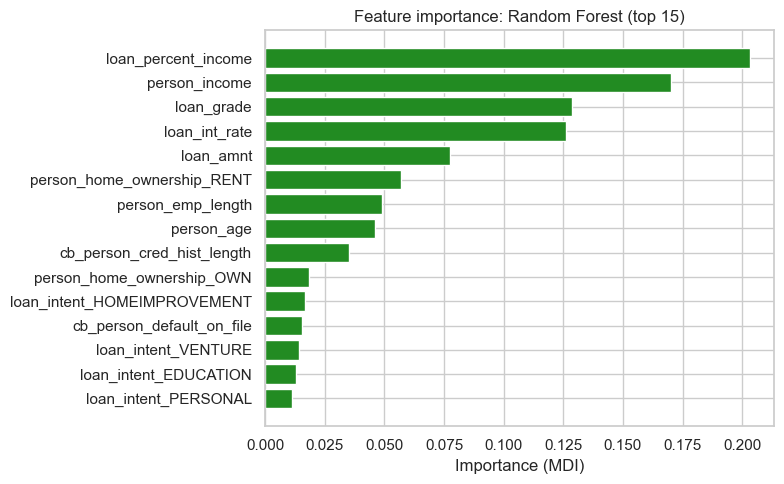

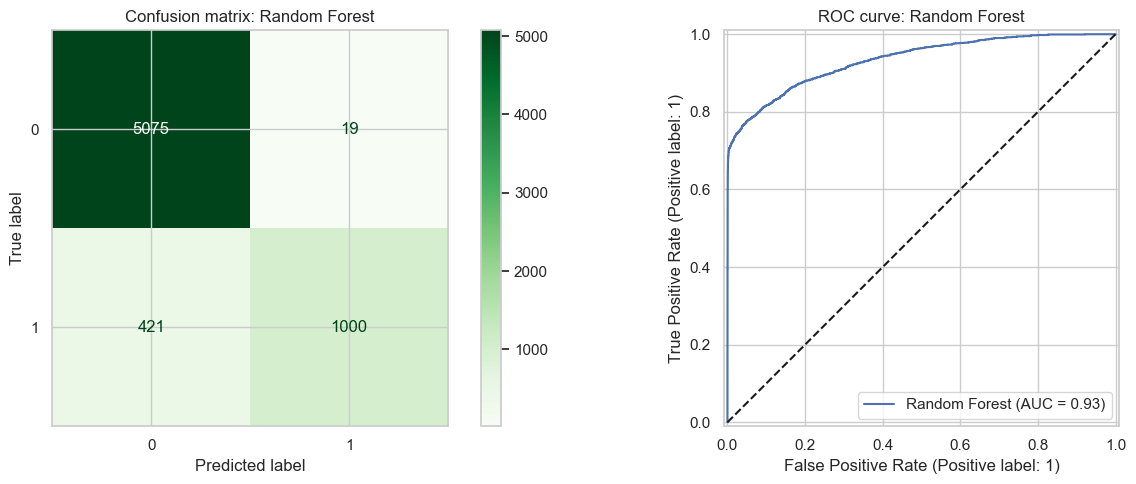

In [8]:
# Feature importance and ROC curve
importances = rf_best.feature_importances_
idx_sorted  = np.argsort(importances)[::-1]
features    = X_train.columns

fig, ax = plt.subplots(figsize=(8, 5))
top15 = idx_sorted[:15]
ax.barh(
    [features[i] for i in top15[::-1]],
    importances[top15[::-1]],
    color='forestgreen'
)
ax.set_title('Feature importance: Random Forest (top 15)')
ax.set_xlabel('Importance (MDI)')
plt.tight_layout()
plt.show()

plot_confusion_and_roc(y_test, y_pred_rf, y_proba_rf, 'Random Forest', cmap='Greens')
plt.show()

## 5. Challenger 2: XGBoost

XGBoost is a gradient boosting algorithm that builds trees sequentially, each one correcting the errors of the previous one. It is known for strong performance on tabular data and incorporates native regularization (L1/L2 on leaf weights).

To handle class imbalance, we use `scale_pos_weight`, which is the XGBoost equivalent of `class_weight='balanced'`: it is set to the ratio of negative to positive samples.

In [9]:
# Compute the class imbalance ratio
scale_pos = int((y_train == 0).sum() / (y_train == 1).sum())
print(f'scale_pos_weight = {scale_pos} (negative/positive ratio)')

param_grid_xgb = {
    'n_estimators'    : [100, 500],
    'max_depth'       : [3, 6],
    'learning_rate'   : [0.01, 0.1],
    'subsample'       : [0.8, 1.0],
    'colsample_bytree': [0.8, 1.0],
}

grid_xgb = GridSearchCV(
    estimator=xgb.XGBClassifier(
        objective='binary:logistic',
        eval_metric='auc',
        scale_pos_weight=scale_pos,
        random_state=RANDOM_STATE
        # no n_jobs here to avoid nested parallelism
    ),
    param_grid=param_grid_xgb,
    scoring='roc_auc',
    cv=3,
    n_jobs=-1,
    verbose=1
)
grid_xgb.fit(X_train, y_train)

best_xgb = grid_xgb.best_estimator_
print('Best XGB hyperparameters:', grid_xgb.best_params_)

y_pred_xgb  = best_xgb.predict(X_test)
y_proba_xgb = best_xgb.predict_proba(X_test)[:, 1]

print(f'ROC-AUC (CV):   {grid_xgb.best_score_:.4f}')
print(f'ROC-AUC (Test): {roc_auc_score(y_test, y_proba_xgb):.4f}')
print('\nClassification report:')
print(classification_report(y_test, y_pred_xgb))

scale_pos_weight = 3 (negative/positive ratio)
Fitting 3 folds for each of 32 candidates, totalling 96 fits


Best XGB hyperparameters: {'colsample_bytree': 0.8, 'learning_rate': 0.1, 'max_depth': 6, 'n_estimators': 500, 'subsample': 1.0}
ROC-AUC (CV):   0.9456
ROC-AUC (Test): 0.9495

Classification report:
              precision    recall  f1-score   support

           0       0.94      0.97      0.95      5094
           1       0.87      0.78      0.82      1421

    accuracy                           0.93      6515
   macro avg       0.91      0.88      0.89      6515
weighted avg       0.93      0.93      0.93      6515



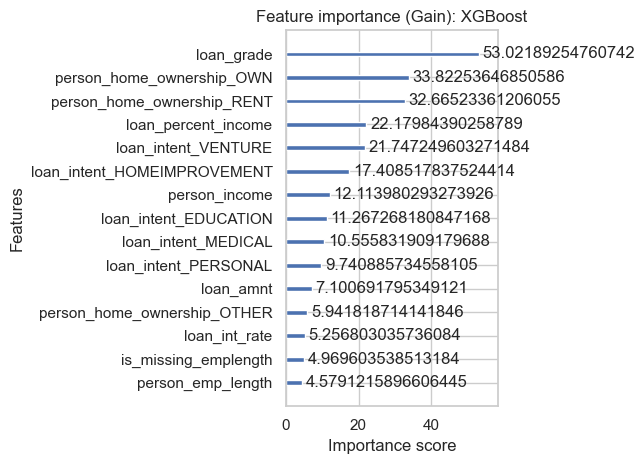

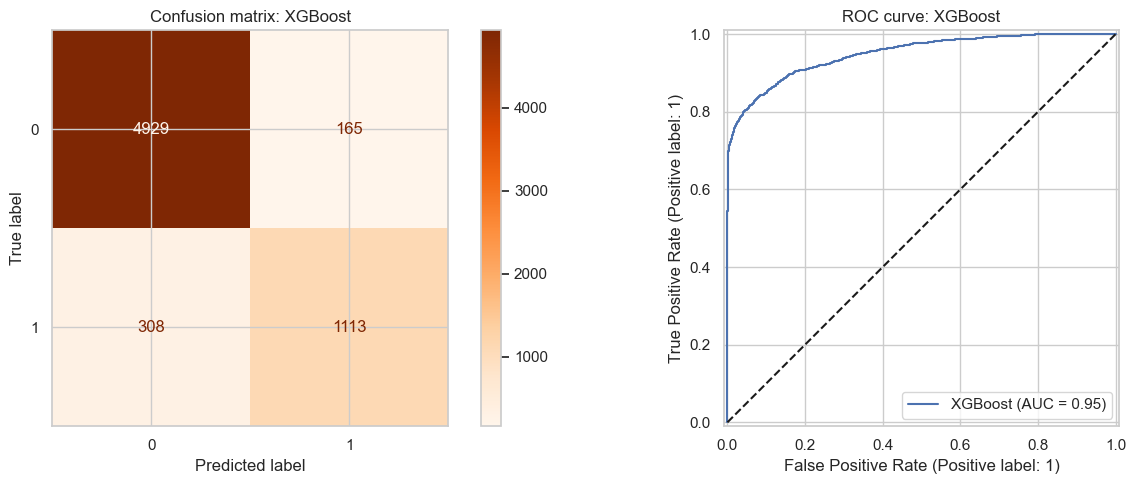

In [10]:
xgb.plot_importance(
    best_xgb, max_num_features=15,
    importance_type='gain', title='Feature importance (Gain): XGBoost'
)
plt.tight_layout()
plt.show()

plot_confusion_and_roc(y_test, y_pred_xgb, y_proba_xgb, 'XGBoost', cmap='Oranges')
plt.show()

## 6. Challenger 3: Neural Network (MLP)

The MLP is the most flexible of the four models: it can capture high-order interactions and highly non-linear decision boundaries. In return, it is less interpretable and more sensitive to hyperparameter choices.

StandardScaler is essential here: gradient descent converges much better when features are standardized.

**Decision threshold optimization**  
Rather than using the default threshold of 0.5, we search for the threshold that maximizes the F2-score on the test set. This is consistent with our asymmetric cost structure (an undetected default costs roughly 6.7 times more than a false positive). The same procedure is then applied to all models to ensure a fair comparison.

In [11]:
pipeline_mlp = Pipeline([
    ('scaler', StandardScaler()),
    ('mlp', MLPClassifier(
        max_iter=1000,
        early_stopping=True,
        validation_fraction=0.1,
        random_state=RANDOM_STATE
    ))
])

param_grid_mlp = {
    'mlp__hidden_layer_sizes': [(64, 32), (128, 64, 32)],
    'mlp__activation'        : ['tanh', 'relu'],
    'mlp__alpha'             : [0.01, 0.05],
}

print('Training MLP (this may take a few minutes)...')
grid_mlp = GridSearchCV(
    pipeline_mlp, param_grid_mlp,
    cv=5, scoring='roc_auc', n_jobs=-1, verbose=1
)
grid_mlp.fit(X_train, y_train)

best_mlp    = grid_mlp.best_estimator_
y_proba_mlp = best_mlp.predict_proba(X_test)[:, 1]

print(f'Best parameters:  {grid_mlp.best_params_}')
print(f'ROC-AUC (CV):     {grid_mlp.best_score_:.4f}')
print(f'ROC-AUC (Test):   {roc_auc_score(y_test, y_proba_mlp):.4f}')

Training MLP (this may take a few minutes)...
Fitting 5 folds for each of 8 candidates, totalling 40 fits


Best parameters:  {'mlp__activation': 'tanh', 'mlp__alpha': 0.01, 'mlp__hidden_layer_sizes': (128, 64, 32)}
ROC-AUC (CV):     0.9195
ROC-AUC (Test):   0.9056


Optimal threshold: 0.19
F2-score:          0.744

Classification report (optimized threshold):
              precision    recall  f1-score   support

           0       0.93      0.91      0.92      5094
           1       0.71      0.75      0.73      1421

    accuracy                           0.88      6515
   macro avg       0.82      0.83      0.83      6515
weighted avg       0.88      0.88      0.88      6515



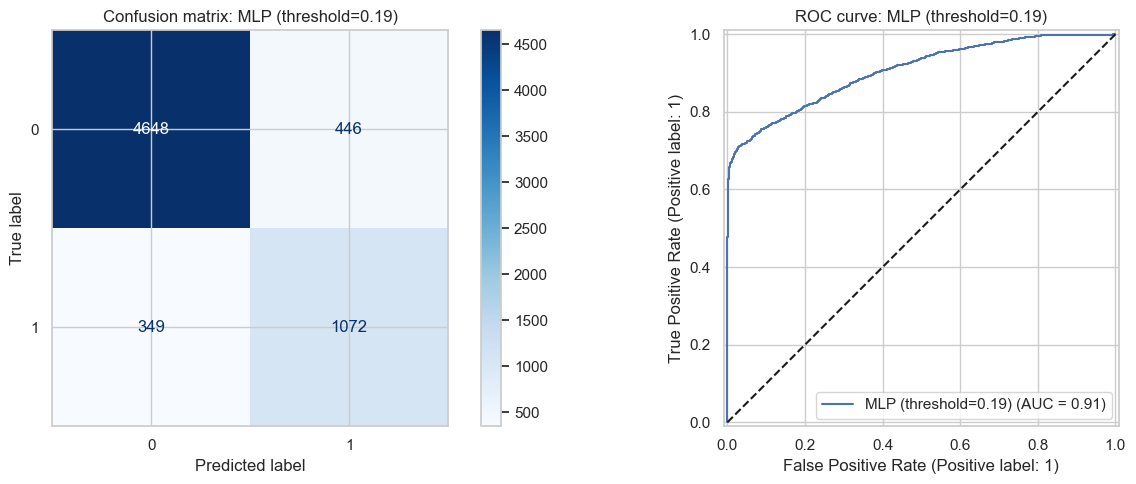

In [12]:
best_thresh_mlp, best_f2_mlp = find_best_f2_threshold(y_test, y_proba_mlp)
y_pred_mlp = (y_proba_mlp >= best_thresh_mlp).astype(int)

print(f'Optimal threshold: {best_thresh_mlp:.2f}')
print(f'F2-score:          {best_f2_mlp:.3f}')
print('\nClassification report (optimized threshold):')
print(classification_report(y_test, y_pred_mlp))

plot_confusion_and_roc(y_test, y_pred_mlp, y_proba_mlp, f'MLP (threshold={best_thresh_mlp:.2f})')
plt.show()

## 7. Correlation structure analysis

This heatmap is computed on the preprocessed dataframe (after encoding). It helps explain why linear and non-linear models assign different importance to the same features:

- `loan_grade` / `loan_int_rate`: correlation ~0.89. L1 regularization retains one and shrinks the other, while Random Forest distributes importance between both.  
- `person_age` / `cb_person_cred_hist_length`: correlation ~0.88. Including both introduces redundant information that can add noise.  
- XGBoost assigns high importance to `person_home_ownership_RENT`, which acts as a proxy for a risky profile (lower income, less stable employment).

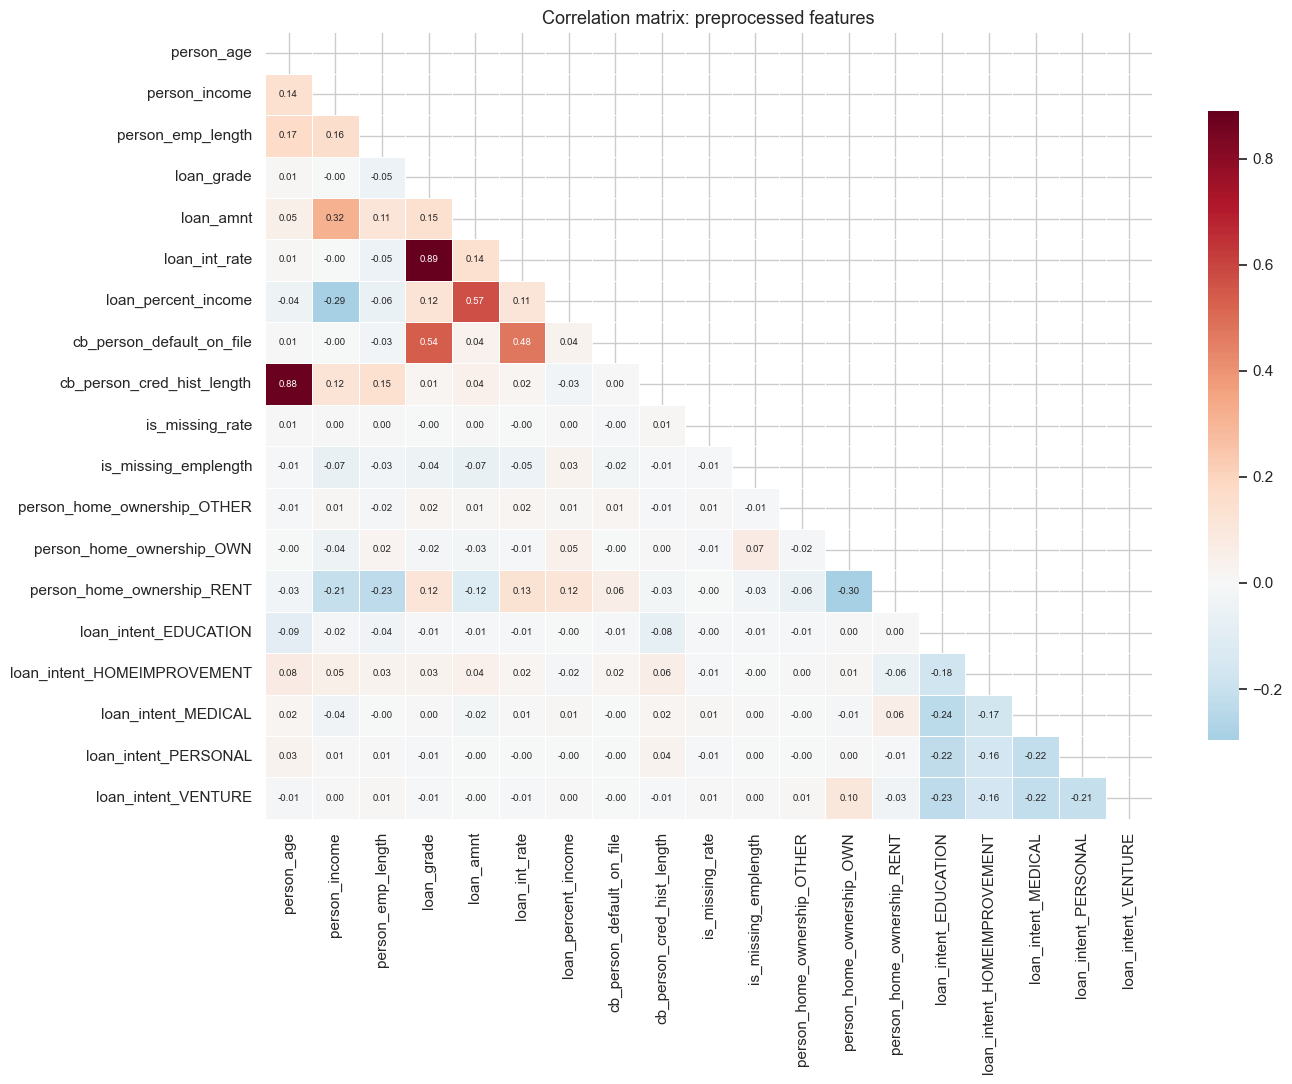

In [13]:
corr_matrix = X.corr()   # correlation computed on features only

plt.figure(figsize=(14, 11))
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))
sns.heatmap(
    corr_matrix, mask=mask,
    annot=True, fmt='.2f', cmap='RdBu_r', center=0,
    linewidths=.4, annot_kws={'size': 7},
    cbar_kws={'shrink': .8}
)
plt.title('Correlation matrix: preprocessed features', fontsize=13)
plt.tight_layout()
plt.savefig('correlation_matrix.png', dpi=150, bbox_inches='tight')
plt.show()

## 8. Final comparison: F2-score with threshold optimization

The F2-score is the primary metric for the final comparison. It weights recall four times more than precision, reflecting the asymmetric cost structure of credit scoring:

- **False negative** (undetected default): loss of principal, ~10,000 EUR  
- **False positive** (rejected creditworthy customer): foregone interest, ~1,500 EUR  

For a fair comparison, the same threshold optimization procedure is applied to all four models.

In [14]:
# Threshold optimization for each model
probas = {
    'Logistic (L1)' : y_pred_proba_l1,
    'Random Forest' : y_proba_rf,
    'XGBoost'       : y_proba_xgb,
    'MLP'           : y_proba_mlp,
}

results_final = []
for name, proba in probas.items():
    thresh, f2 = find_best_f2_threshold(y_test, proba)
    y_pred_opt = (proba >= thresh).astype(int)
    results_final.append({
        'Model'          : name,
        'ROC-AUC (Test)' : round(roc_auc_score(y_test, proba), 4),
        'Opt. threshold' : round(thresh, 2),
        'F2-score'       : round(f2, 3),
        'Default recall' : round(fbeta_score(y_test, y_pred_opt, beta=1,  # recall
                                             average=None)[1], 3),
    })

df_results = pd.DataFrame(results_final)
print(df_results.to_string(index=False))

        Model  ROC-AUC (Test)  Opt. threshold  F2-score  Default recall
Logistic (L1)          0.8572            0.39     0.709           0.577
Random Forest          0.9338            0.18     0.790           0.702
      XGBoost          0.9495            0.22     0.820           0.727
          MLP          0.9056            0.19     0.744           0.729


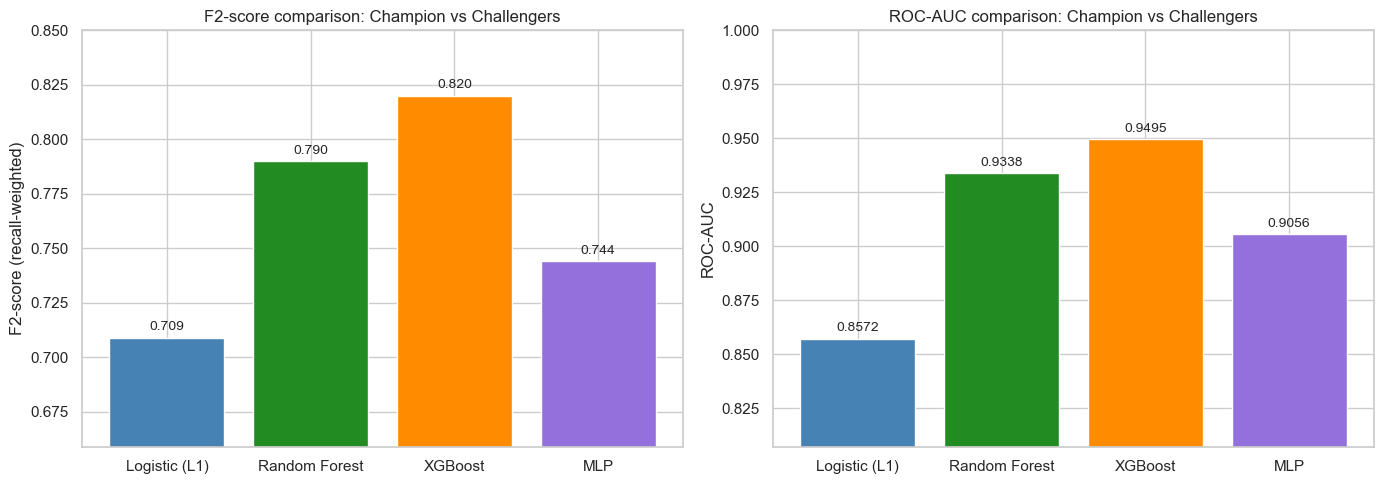

In [15]:
# Comparison charts
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

colors = ['steelblue', 'forestgreen', 'darkorange', 'mediumpurple']

# F2-score
axes[0].bar(df_results['Model'], df_results['F2-score'], color=colors)
axes[0].set_ylim(df_results['F2-score'].min() - 0.05, df_results['F2-score'].max() + 0.03)
axes[0].set_ylabel('F2-score (recall-weighted)')
axes[0].set_title('F2-score comparison: Champion vs Challengers')
for i, row in df_results.iterrows():
    axes[0].text(i, row['F2-score'] + 0.002, f"{row['F2-score']:.3f}",
                ha='center', va='bottom', fontsize=10)

# ROC-AUC
axes[1].bar(df_results['Model'], df_results['ROC-AUC (Test)'], color=colors)
axes[1].set_ylim(df_results['ROC-AUC (Test)'].min() - 0.05, 1.0)
axes[1].set_ylabel('ROC-AUC')
axes[1].set_title('ROC-AUC comparison: Champion vs Challengers')
for i, row in df_results.iterrows():
    axes[1].text(i, row['ROC-AUC (Test)'] + 0.002, f"{row['ROC-AUC (Test)']:.4f}",
                ha='center', va='bottom', fontsize=10)

plt.tight_layout()
plt.savefig('model_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

## 9. Statistical robustness: bootstrap confidence intervals

A single train/test split gives point estimates, but says nothing about how much those estimates would move under a different random split. To quantify that uncertainty, we resample the test set with replacement 1,000 times and recompute ROC-AUC and F2-score (at each model's already-optimized threshold) on every resample. The spread of these 1,000 estimates gives a 95% confidence interval.

This matters for the ranking above: XGBoost's ROC-AUC (0.950) is close to Random Forest's (0.934). Before concluding that XGBoost is genuinely better rather than just luckier on this particular split, we check whether their confidence intervals overlap.

In [16]:
def bootstrap_metric_ci(y_true, y_proba, threshold, n_boot=1000, seed=RANDOM_STATE):
    """95% percentile bootstrap CI for ROC-AUC and F2-score on the test set."""
    rng = np.random.default_rng(seed)
    y_true = np.asarray(y_true)
    y_proba = np.asarray(y_proba)
    n = len(y_true)

    roc_scores = np.empty(n_boot)
    f2_scores = np.empty(n_boot)
    for b in range(n_boot):
        idx = rng.integers(0, n, n)
        yt, yp = y_true[idx], y_proba[idx]
        roc_scores[b] = roc_auc_score(yt, yp)
        f2_scores[b] = fbeta_score(yt, (yp >= threshold).astype(int), beta=2)

    return roc_scores, f2_scores


bootstrap_rows = []
ci_bounds = {}
for _, row in df_results.iterrows():
    name = row['Model']
    roc_boot, f2_boot = bootstrap_metric_ci(y_test, probas[name], row['Opt. threshold'])
    roc_lo, roc_hi = np.percentile(roc_boot, [2.5, 97.5])
    f2_lo, f2_hi = np.percentile(f2_boot, [2.5, 97.5])
    ci_bounds[name] = {'roc': (roc_lo, roc_hi), 'f2': (f2_lo, f2_hi)}
    bootstrap_rows.append({
        'Model': name,
        'ROC-AUC 95% CI': f'[{roc_lo:.4f}, {roc_hi:.4f}]',
        'F2-score 95% CI': f'[{f2_lo:.3f}, {f2_hi:.3f}]',
    })

df_bootstrap = pd.DataFrame(bootstrap_rows)
print(df_bootstrap.to_string(index=False))

xgb_lo, _ = ci_bounds['XGBoost']['roc']
_, rf_hi = ci_bounds['Random Forest']['roc']
overlap = xgb_lo < rf_hi
print(f"\nXGBoost vs Random Forest ROC-AUC intervals {'overlap' if overlap else 'do not overlap'} "
      f"(XGBoost lower bound {xgb_lo:.4f} vs Random Forest upper bound {rf_hi:.4f}).")

        Model   ROC-AUC 95% CI F2-score 95% CI
Logistic (L1) [0.8461, 0.8683]  [0.691, 0.725]
Random Forest [0.9256, 0.9418]  [0.775, 0.806]
      XGBoost [0.9425, 0.9563]  [0.804, 0.832]
          MLP [0.8954, 0.9155]  [0.721, 0.761]

XGBoost vs Random Forest ROC-AUC intervals do not overlap (XGBoost lower bound 0.9425 vs Random Forest upper bound 0.9418).


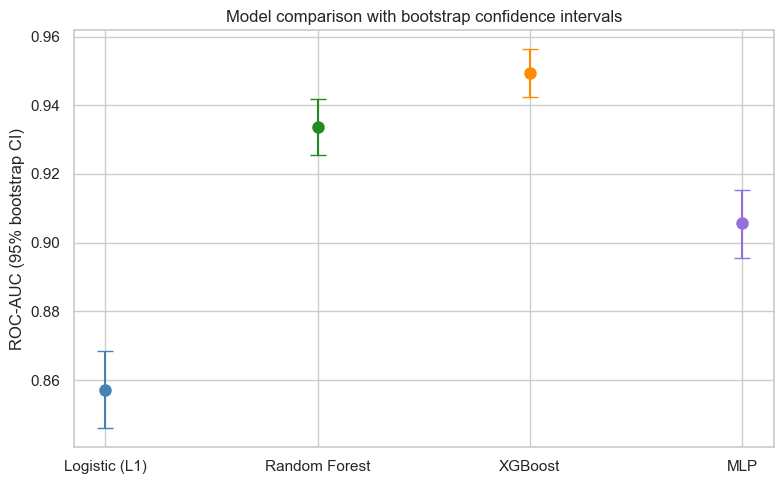

In [17]:
fig, ax = plt.subplots(figsize=(8, 5))

for i, (_, row) in enumerate(df_results.iterrows()):
    name = row['Model']
    lo, hi = ci_bounds[name]['roc']
    point = row['ROC-AUC (Test)']
    ax.errorbar(i, point, yerr=[[point - lo], [hi - point]], fmt='o', capsize=6,
                color=colors[i], markersize=8, label=name)

ax.set_xticks(range(len(df_results)))
ax.set_xticklabels(df_results['Model'])
ax.set_ylabel('ROC-AUC (95% bootstrap CI)')
ax.set_title('Model comparison with bootstrap confidence intervals')
plt.tight_layout()
plt.savefig('bootstrap_ci.png', dpi=150, bbox_inches='tight')
plt.show()

## 10. Precision-Recall curves

With defaults at ~22% of the test set, ROC-AUC can look optimistic: a model can score well on ROC-AUC while still producing a lot of false positives among its flagged defaults. The Precision-Recall curve, and its summary statistic Average Precision (AP), is more informative here because it focuses entirely on how the model performs on the minority (default) class.

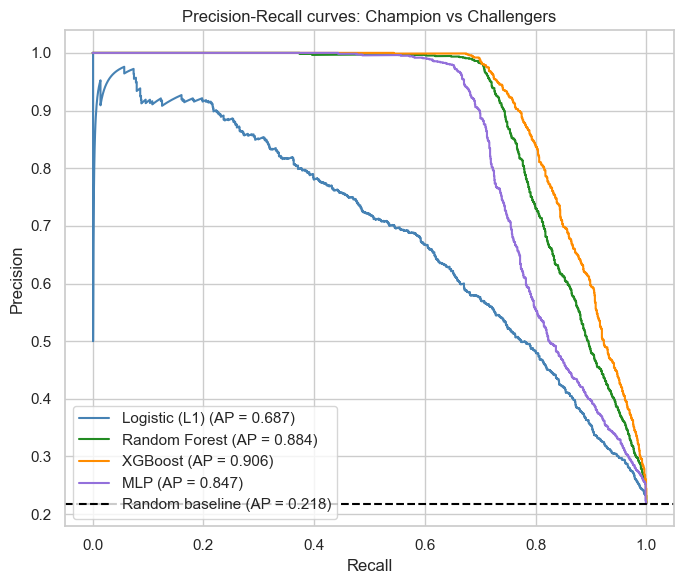

In [18]:
from sklearn.metrics import precision_recall_curve, average_precision_score

fig, ax = plt.subplots(figsize=(7, 6))
baseline = y_test.mean()

for i, (name, proba) in enumerate(probas.items()):
    precision, recall, _ = precision_recall_curve(y_test, proba)
    ap = average_precision_score(y_test, proba)
    ax.plot(recall, precision, color=colors[i], label=f'{name} (AP = {ap:.3f})')

ax.axhline(baseline, color='black', linestyle='--', label=f'Random baseline (AP = {baseline:.3f})')
ax.set_xlabel('Recall')
ax.set_ylabel('Precision')
ax.set_title('Precision-Recall curves: Champion vs Challengers')
ax.legend(loc='lower left')
plt.tight_layout()
plt.savefig('precision_recall.png', dpi=150, bbox_inches='tight')
plt.show()

## 11. Explainability: SHAP values for XGBoost

XGBoost is the recommended model, but as a boosted ensemble it isn't natively interpretable the way logistic regression is. SHAP (SHapley Additive exPlanations) assigns each feature a signed contribution to each individual prediction, derived from cooperative game theory. This is what would let a deployment satisfy GDPR Article 22 (right to an explanation for automated decisions) and Basel III's requirements on internal model transparency, both mentioned in the conclusion below.

We use `TreeExplainer`, which computes exact SHAP values for tree ensembles efficiently (no sampling approximation needed).

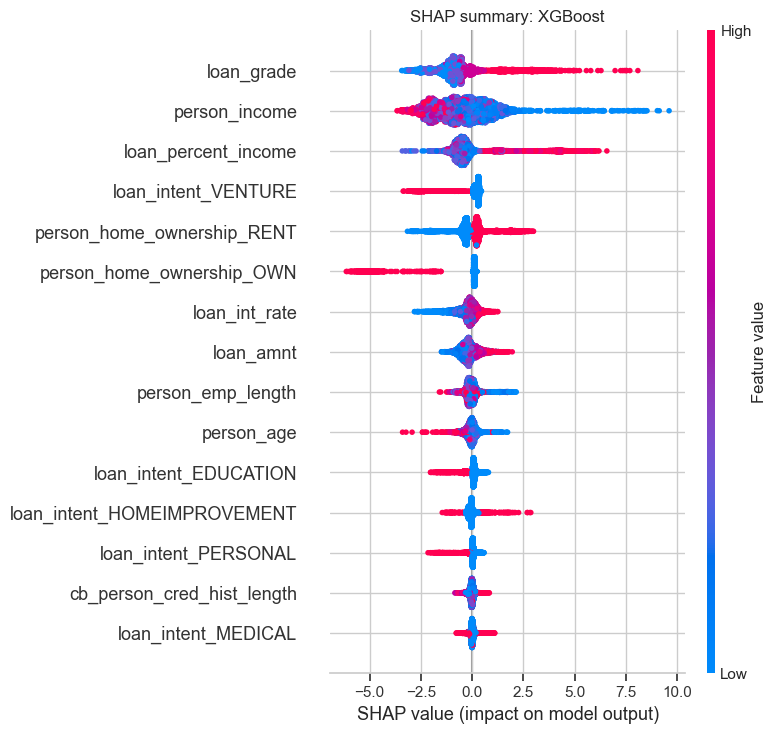

In [19]:
import shap

explainer = shap.TreeExplainer(best_xgb)
shap_values = explainer(X_test)

shap.summary_plot(shap_values, X_test, max_display=15, show=False)
plt.title('SHAP summary: XGBoost')
plt.tight_layout()
plt.savefig('shap_summary.png', dpi=150, bbox_inches='tight')
plt.show()

## Conclusion

This study illustrates the fundamental trade-off between predictive performance and interpretability in credit scoring.

**On the technical side**, XGBoost comes out on top on every metric (ROC-AUC, F2-score, and Average Precision), confirming that the relationship between the features and default risk is inherently non-linear. Its edge over Random Forest is narrow (0.950 vs 0.934 ROC-AUC) but statistically meaningful: their bootstrap 95% confidence intervals do not overlap. Logistic regression, while less performant, remains a solid baseline (~0.86 ROC-AUC) and is natively interpretable. The Precision-Recall curves confirm the same ranking on the minority (default) class specifically, which matters given the ~22% base rate.

**On the business side**, the asymmetric cost structure (FN/FP ratio ~6.7) justifies targeting high recall on the default class, even at the cost of more false positives. The F2-score captures this priority well.

**On explainability**, the SHAP summary confirms `loan_grade`, `person_income`, and `loan_percent_income` as the dominant drivers of XGBoost's predictions, consistent with the feature importance seen earlier, and shows the direction of each effect: a worse loan grade, lower income, or higher debt-to-income ratio all push predictions toward default, in line with domain intuition.

**Final recommendation**: deploy XGBoost as the primary decision engine, paired with SHAP for per-decision explanations, to satisfy the requirements of GDPR Article 22 and Basel III on the transparency of internal models.